In [7]:
from dataclasses import asdict

import pandas as pd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the BPMN Dataset

In [8]:

from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [9]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   0%|          | 0/103 [00:00<?, ?it/s]

Defining file path for saving dataset and loading it later on.

In [10]:
file_path = 'data/bpmnmodelset/processed/reduced/culled_models.csv'


Saving created Dataset
Then remove it from memory to conserve memory.

In [11]:

BPMNDataset.to_csv(bpmn_dataset, file_path);
print(bpmn_dataset.models.memory_usage().sum())
del(bpmn_dataset)


2910084


Load BPMN Models with reduced size of model back from file to ensure saving and writing is repeatable

In [15]:
from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv

loaded_dataset = load_dataset_from_csv("sam_culled_models", file_path)
print(loaded_dataset.models.memory_usage().sum())


2910084


In [16]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

extract_names_from_models(loaded_dataset, use_types=False)
models_with_names_file_path = 'data/bpmnmodelset/processed/reduced/culled_with_names.csv'

BPMNDataset.to_csv(loaded_dataset, models_with_names_file_path);

Extracting names from raw model done.


In [14]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

loaded_dataset = load_dataset_from_csv("sam_reduced_models", file_path)

extract_names_from_models(loaded_dataset, use_types=True)
models_with_typed_names_file_path = 'data/bpmnmodelset/processed/reduced/culled_with_typed_names.csv'

BPMNDataset.to_csv(loaded_dataset, models_with_typed_names_file_path);

Extracting names_with_types from raw model done.


Duplicate Detection on already computed hashes took 0.01 seconds.
Total number of models: 30312
Total unique files: 18639
Total duplicate files: 11673
Duplicate groups: 213


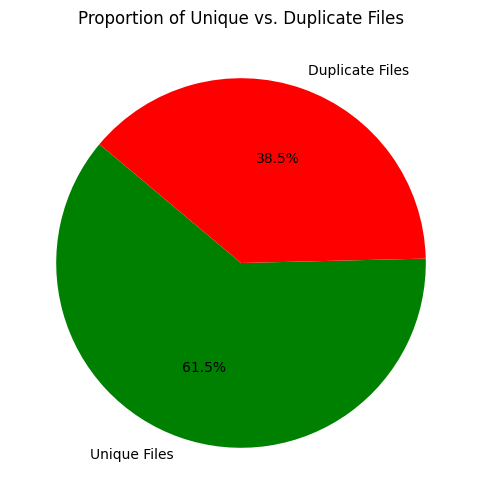

In [17]:
from mcp4cm.bpmn.deduplication import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=False, plt_fig=True)


In [18]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from langdetect import detect
from collections import defaultdict


def tfidf_near_duplicate_detector(
        dataset: BPMNDataset,
        threshold: float = 0.8,
        inplace: bool = False,
        plt_fig: bool = False,
        print_results: bool = True,
):
    def get_content(names_list: list)-> str:
        # Join with filter on empty strings
        content = " ".join(names_list)
        return content

    def get_language(content: str) -> str:
        striped_content = content.strip()
        if striped_content:
            return detect(striped_content)
        return None


    content_series = dataset.models['names'].apply(get_content)
    #language_series = content_series.apply(get_language)

    vectorizer = TfidfVectorizer()
    tf_idf_matrix = vectorizer.fit_transform(content_series)
    similarity_matrix = cosine_similarity(tf_idf_matrix)
    similarity_threshold = threshold

    # Initialize groups of duplicates
    duplicate_groups = defaultdict(list)
    unique_files_indices = content_series.index # Track indices of potentially unique files
    non_unique_indices = list()
    # Efficient file comparison
    for i in range(len(unique_files_indices)):
        found_group = False

        model_id = dataset.models.at[i,'id']

        for group_id, members in list(duplicate_groups.items()):

            for member_index in members:
                if member_index != i and similarity_matrix[i][member_index] > similarity_threshold:
                    duplicate_groups[group_id].append(i)
                    found_group = True
                    non_unique_indices.append(i)
                    break
            if found_group:
                break


        # If no existing group is similar, start a new group
        if not found_group and i not in non_unique_indices:
            duplicate_groups[model_id].append(i)

    unique_files_indices = unique_files_indices.difference(non_unique_indices)

    near_duplicate_count = sum(len(indices) for indices in duplicate_groups.values() if len(indices) > 1)
    number_of_duplicate_groups = sum(1 for indices in duplicate_groups.values() if len(indices) > 1)
    unique_file_count = len(unique_files_indices) - number_of_duplicate_groups
    total_files_processed = near_duplicate_count + unique_file_count

    if print_results:
        print("\n=== Dataset Statistics ===")
        print(f"Total files processed: {total_files_processed}")
        print(f"Total unique files: {unique_file_count}")
        print(f"Total duplicate files: {near_duplicate_count}")
        print(f"Number of duplicate groups: {number_of_duplicate_groups}")

    return (near_duplicate_count/total_files_processed), number_of_duplicate_groups

In [19]:
loaded_dataset.models.iloc[0]['names']

['',
 '',
 'Konobar\n',
 '',
 'Narudžba primljena\n',
 '',
 '',
 'Narudžba / kupac\n',
 '',
 '',
 'Narudžba pive\n',
 'Izaberi pivu \n',
 'Želja za pivom\n']

In [21]:
file_path = 'data/bpmnmodelset/processed/reduced/culled_with_names.csv'
reloaded_dataset = load_dataset_from_csv("sam_reduced_models", file_path)
type(reloaded_dataset.models.iloc[0]['names'])



list

In [22]:
reloaded_dataset.models.iloc[0]['names']

['',
 '',
 'Konobar\n',
 '',
 'Narudžba primljena\n',
 '',
 '',
 'Narudžba / kupac\n',
 '',
 '',
 'Narudžba pive\n',
 'Izaberi pivu \n',
 'Želja za pivom\n']

In [23]:

steps = [x*0.1 for x in range(11)]
print(steps)

percent_near_duplicates = list()
number_of_duplicate_groups = list()



for step in steps:
    percentage, n_groups = tfidf_near_duplicate_detector(loaded_dataset, threshold=step, inplace=False, plt_fig=False, print_results=False)
    percent_near_duplicates.append(percentage)
    number_of_duplicate_groups.append(n_groups)





[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


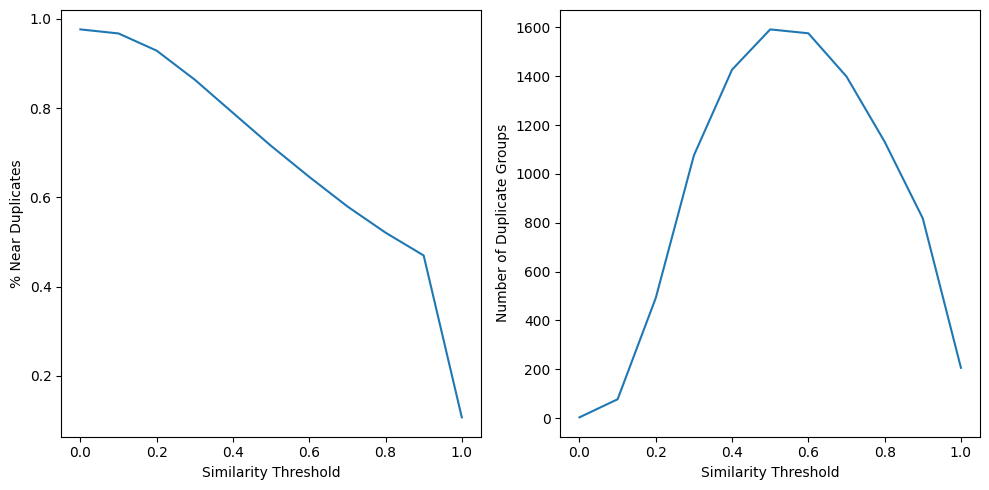

In [24]:
from mcp4cm.bpmn.plotting_util import plot_tf_idf_graphs

plot_tf_idf_graphs(steps, percent_near_duplicates, number_of_duplicate_groups)

In [ ]:
#english_files = language_series[language_series == 'en']

tfidf_near_duplicate_detector(loaded_dataset, threshold=0.8, inplace=False, plt_fig=False)

In [ ]:
from collections import defaultdict

hash_to_files = defaultdict(list)
output_txt_file = "hashing_results.txt"

for i in range(n_models):
    hash_to_files[hashes[i]].append(i)


duplicate_files = {h: files for h, files in hash_to_files.items() if len(files) > 1}
unique_files = {h: files[0] for h, files in hash_to_files.items() if len(files) == 1}

# Save results to a text file
with open(output_txt_file, 'w', encoding='utf-8') as txt_file:
    txt_file.write("=== Duplicate BPMN Files Detected ===\n")
    if duplicate_files:
        for file_hash, files in duplicate_files.items():
            txt_file.write(f"\nDuplicate Group (Hash: {file_hash}):\n")
            for file in files:
                txt_file.write(f"  - {file}\n")
    else:
        txt_file.write("No duplicate name files found.\n")

    txt_file.write("\n=== Unique BPMN  Files (No Duplicates) ===\n")
    if unique_files:
        for file_hash, file in unique_files.items():
            txt_file.write(f"\nUnique File (Hash: {file_hash}):\n  - {file}\n")
    else:
        txt_file.write("No unique files found.\n")

# Print execution time
print(f"Results saved to: {output_txt_file}")